#### Questão 5

# Oscilador digital baseado em resposta ao impulso senoidal

## A): Função de transferência e equação de diferenças

Dado um sistema LTI cuja **resposta ao impulso** é

$$
h[n] = A \sin(\omega_0 n + \phi)\, u[n],
$$

sua **função de transferência** é o Z-transformado de $ h[n] $:

$$
H(z) = \mathcal{Z}\{A\sin(\omega_0 n + \phi)u[n]\}.
$$

Usando a identidade trigonométrica:

$$
\sin(\omega_0 n + \phi) 
= \sin(\phi)\cos(\omega_0 n) + \cos(\phi)\sin(\omega_0 n),
$$

e aplicando o par de transformadas conhecido:

$$
\mathcal{Z}\{\sin(\omega_0 n)\} = \frac{z^{-1}\sin(\omega_0)}{1 - 2\cos(\omega_0)z^{-1} + z^{-2}},
$$

$$
\mathcal{Z}\{\cos(\omega_0 n)\} = \frac{1 - z^{-1}\cos(\omega_0)}{1 - 2\cos(\omega_0)z^{-1} + z^{-2}},
$$

podemos escrever:

$$
H(z) = 
A\frac{
\sin(\phi)(1 - z^{-1}\cos\omega_0)
+ \cos(\phi)\,z^{-1}\sin\omega_0
}{
1 - 2\cos(\omega_0)z^{-1} + z^{-2}
}.
$$

O denominador mostra que o sistema é um **filtro ressonante de segunda ordem**, cuja equação de diferenças geral é:

$$
y[n] - 2\cos(\omega_0)\,y[n-1] + y[n-2] = x[n]*(\text{termos do numerador}).
$$

No caso de osciladores digitais (entrada nula), deseja-se apenas a parte homogênea:

$$
\boxed{
y[n] = 2\cos(\omega_0)\,y[n-1] - y[n-2]
}
$$

Esta é a equação clássica de um **oscilador recursivo sem entrada**, usada em geradores de DDS e síntese digital.

---

## B): Relação entre frequência discreta e analógica

A frequência angular discreta $ \omega_0 $ relaciona-se com a frequência analógica $ f_0 $ e com a frequência de amostragem $ f_s $:

$$
\boxed{
\omega_0 = 2\pi \frac{f_0}{f_s}
}
$$

#### C)

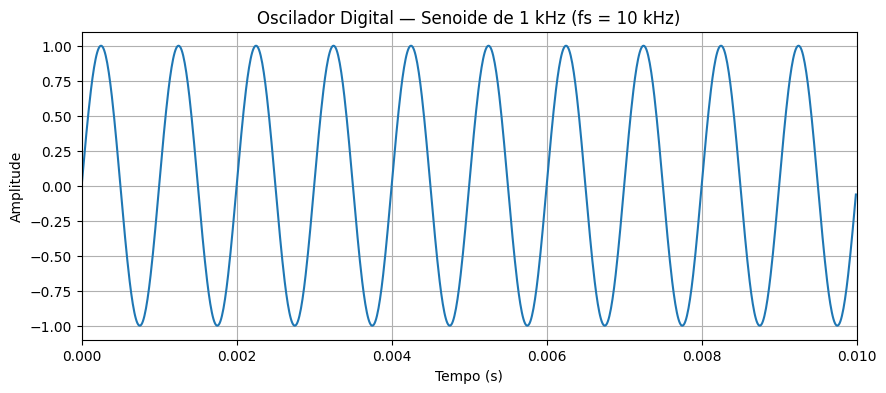

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Parâmetros -----
A = 1
phi = 0
f0 = 1000      # Hz
fs = 100000    # Hz
T = 0.01       # duração em segundos

omega0 = 2 * np.pi * f0 / fs   # frequência angular discreta
N = int(T * fs)                # número de amostras

# ----- Vetor de saída y[n] -----
y = np.zeros(N)

# Condições iniciais
y[0] = np.sin(phi) 
y[1] = np.sin(omega0 + phi) 

# ----- Implementação do oscilador (equação de diferenças) -----
for n in range(2, N):
    y[n] = 2*np.cos(omega0)*y[n-1] - y[n-2]

# ----- Vetor de tempo -----
t = np.arange(N) / fs

# ----- Plot -----
plt.figure(figsize=(10,4))
plt.plot(t, y, label='Sinal gerado')
plt.title('Oscilador Digital — Senoide de 1 kHz (fs = 10 kHz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([0, 0.01])
plt.show()


#### D)

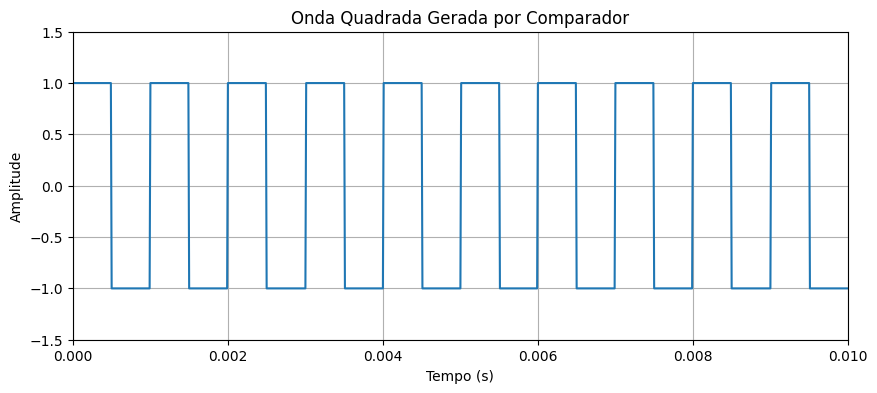

In [9]:
# y = sinal senoidal gerado anteriormente
# t = vetor de tempo correspondente

# Implementação do comparador
y_sq = np.where(y >= 0, 1, -1)

# --- Plot da onda quadrada ---
plt.figure(figsize=(10,4))
plt.plot(t, y_sq, label="Saída do comparador")
plt.title("Onda Quadrada Gerada por Comparador")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim([0, 0.01])
plt.ylim([-1.5, 1.5])
plt.show()


#### E)

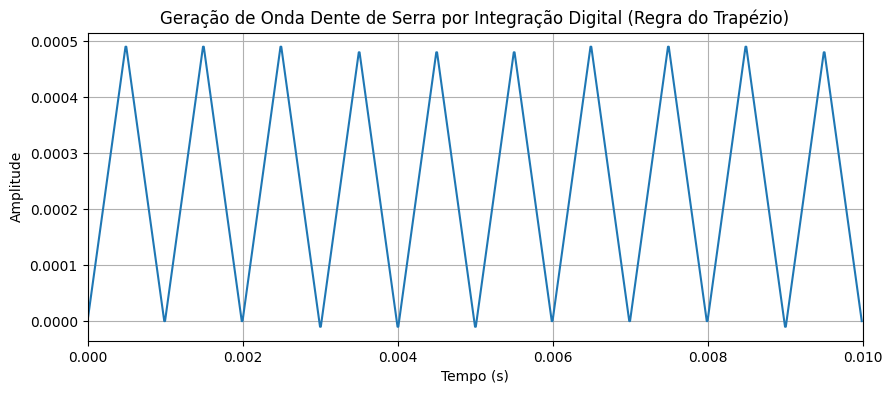

In [ ]:
# y_sq : sinal quadrado gerado no item (d)
# t    : vetor de tempo correspondente
# fs   : frequência de amostragem

Ts = 1/fs
N = len(y_sq)

# Vetor de saída do integrador
y_tri = np.zeros(N)

# Implementação do integrador por trapézio
for n in range(1, N):
    y_tri[n] = y_tri[n-1] + (Ts/2) * (y_sq[n] + y_sq[n-1])

# ---- Plot ----
plt.figure(figsize=(10,4))
plt.plot(t, y_tri, label="Sinal dente de serra (integrado)")
plt.title("Geração de Onda Dente de Serra por Integração Digital (Regra do Trapézio)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim([0, 0.01])
plt.show()
